# Library imports and setting file path

In [1]:
import os
import sys
import warnings
import pandas as pd
import geopandas as gpd

ROOT = os.path.abspath(".")
PY_SCRIPTS = os.path.join(ROOT, "py_scripts")
sys.path.insert(0, PY_SCRIPTS)

from parse_adjacency import parse_adjacency, load_adjacency
from parse_county_data import parse_county_data, load_county_data
from min_coverage import solve_min_coverage
from equitable_placement import solve_equitable
from helper_functions import STATE_FIPS_TO_NAME, plot_centers


SHP_PATH = os.path.join(ROOT, "county_data", "cb_2023_us_county_500k", "cb_2023_us_county_500k.shp")
ADJ_PATH = os.path.join(ROOT, "county_data", "county_adjacency.txt")
DEMO_PATH = os.path.join(ROOT, "county_data", "county_demographics.csv")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# User defines desired state of interest and k value for equitable placement model

In [2]:
STATE_NAME = "Nebraska"
STATE_FIPS = {name: fips for fips, name in STATE_FIPS_TO_NAME.items()}[STATE_NAME]

k = 5

# Parse adjacency and county data

In [3]:
parse_adjacency(ADJ_PATH, STATE_FIPS)
parse_county_data(DEMO_PATH, STATE_FIPS)
adj = load_adjacency(STATE_FIPS)
cdata = load_county_data(STATE_FIPS)

# Load shapefile and filter to desired state

In [4]:
shp = gpd.read_file(SHP_PATH)
state_shp = shp[shp["STATEFP"] == STATE_FIPS]
state_shp = state_shp.to_crs(state_shp.estimate_utm_crs())

# Solve Minimum Coverage Problem

Set parameter Username
Set parameter LicenseID to value 2764175
Academic license - for non-commercial use only - expires 2027-01-13
Min coverage: 16 centers, objective 16.0, 0.0130s


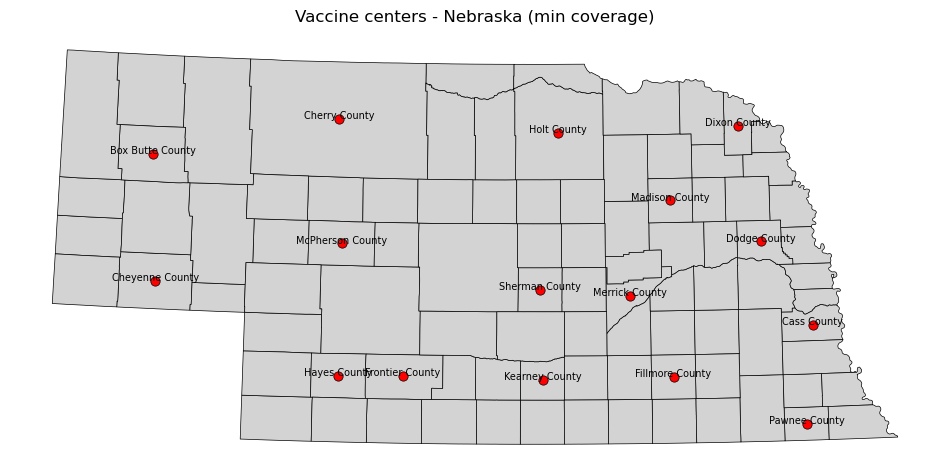

In [5]:
centers_a, obj_a, time_a = solve_min_coverage(adj, cdata)
print(f"Min coverage: {len(centers_a)} centers, objective {obj_a}, {time_a:.4f}s")
plot_centers(state_shp, cdata, centers_a, "min coverage")

In [6]:
df_a = pd.DataFrame(
    [
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_a,
        }
        for fips, data in cdata.items()
    ]
)
display(df_a)

,FIPS,County,Population,Is_Center
0,31001,Adams County,31071,False
1,31003,Antelope County,6352,False
2,31005,Arthur County,396,False
3,31007,Banner County,686,False
4,31009,Blaine County,458,False
5,31011,Boone County,5355,False
6,31013,Box Butte County,10494,True
7,31015,Boyd County,1674,False
8,31017,Brown County,2826,False
9,31019,Buffalo County,51172,False


# Solve Equitable Placement Problem

Equitable (k=5): 5 centers, objective 36964277.46, 0.1203s


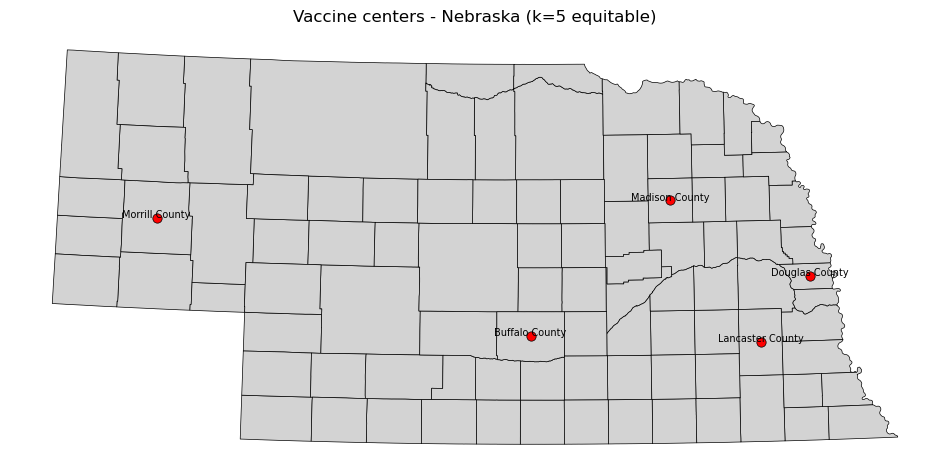

In [7]:
centers_b, obj_b, time_b, assigned = solve_equitable(cdata, k)
print(
    f"Equitable (k={k}): {len(centers_b)} centers, objective {obj_b:.2f}, {time_b:.4f}s"
)
plot_centers(state_shp, cdata, centers_b, f"k={k} equitable")

In [8]:
df_b = pd.DataFrame(
    [
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_b,
            "Assigned_To": assigned.get(fips),
        }
        for fips, data in cdata.items()
    ]
)
display(df_b)

,FIPS,County,Population,Is_Center,Assigned_To
0,31001,Adams County,31071,False,31019
1,31003,Antelope County,6352,False,31119
2,31005,Arthur County,396,False,31123
3,31007,Banner County,686,False,31123
4,31009,Blaine County,458,False,31019
5,31011,Boone County,5355,False,31119
6,31013,Box Butte County,10494,False,31123
7,31015,Boyd County,1674,False,31119
8,31017,Brown County,2826,False,31019
9,31019,Buffalo County,51172,True,31019
